# Inertia Intervention Effectiveness Analysis

Evaluates the **prompt intervention system** introduced in `inertia_checker.py`:  
after each shard is revealed, the hidden-state trajectory is checked against two metrics;
if either fails the assistant's next prompt is augmented with a corrective instruction.

## Two detection criteria (from `conversation_analysis_v4.ipynb`)

| Metric | Formula | Correct-path signal | Threshold |
|--------|---------|--------------------|-----------|
| **Temporal Curvature κ** | `cos(Δh_t, Δh_{t-1})` | higher κ → consistent momentum | κ < −0.2 → fail |
| **Trajectory Variance Slope** | slope of `trace(Cov)` over prefix t | higher slope → expanding exploration | slope < 0 → fail |

## Notebook structure

| Section | Content |
|---------|---------|
| **§1** | Setup: imports, paths, utilities |
| **§2** | Data loading: parse inertia logs from JSONL |
| **§3** | Intervention audit: when/why does it fire? |
| **§4** | Accuracy comparison: baseline vs intervention run |
| **§5** | Trajectory recovery: hidden-state geometry before/after intervention |
| **§6** | Threshold calibration: optimal κ & var_slope cutoffs |
| **§7** | Summary & recommendations |

## §1  Setup

In [149]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

from collections import Counter, defaultdict
from pathlib import Path
from scipy.stats import mannwhitneyu, fisher_exact, linregress
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from matplotlib.patches import Patch
from itertools import chain

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Baseline: no inertia check (add_v2 prompt-addition experiment)
JSONL_BASELINE = Path("logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl")
PT_BASELINE    = Path("logs/hidden_states/math/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct")

# Inertia run: curvature + variance slope checks with prompt intervention
JSONL_INERTIA  = Path("logs/math/sharded-at0-ut0/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl")
PT_INERTIA     = Path("logs/hidden_states/math/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct")

# ── Layer config (must match ActivationTracker) ───────────────────────────────
LAYERS          = [12, 16, 20, 24, 28]
FOCUS_LAYER_IDX = LAYERS.index(20)   # layer 20 is InertiaChecker's default focus

# ── Inertia thresholds (must match InertiaChecker defaults) ───────────────────
CURV_THRESHOLD = -0.2
VAR_THRESHOLD  =  0.0

print(f"Baseline JSONL : {JSONL_BASELINE}  exists={JSONL_BASELINE.exists()}")
print(f"Inertia JSONL  : {JSONL_INERTIA}   exists={JSONL_INERTIA.exists()}")
print(f"Focus layer    : {LAYERS[FOCUS_LAYER_IDX]} (index {FOCUS_LAYER_IDX})")

Baseline JSONL : logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl  exists=True
Inertia JSONL  : logs/math/sharded-at0-ut0/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl   exists=True
Focus layer    : 20 (index 2)


In [135]:
# ── Utilities ─────────────────────────────────────────────────────────────────

def binary_score(rec: dict) -> int:
    """1 if conversation was solved correctly, else 0."""
    ic = rec.get("is_correct")
    s  = rec.get("score")
    if ic in (True, 1, 1.0): return 1
    if s  in (1, 1.0):       return 1
    return 0

def cosine(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9: return float("nan")
    return float(np.dot(a, b) / (na * nb))

def mw_test(vc, vi, alternative="two-sided"):
    if len(vc) < 5 or len(vi) < 5: return "—", float("nan")
    _, p = mannwhitneyu(vc, vi, alternative=alternative)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    return star, p

def ci95_proportion(n_success: int, n_total: int):
    """Wilson score 95% CI."""
    if n_total == 0: return (0, 0)
    p = n_success / n_total
    z = 1.96
    denom = 1 + z**2 / n_total
    centre = (p + z**2 / (2*n_total)) / denom
    margin = z * math.sqrt(p*(1-p)/n_total + z**2/(4*n_total**2)) / denom
    return (max(0, centre - margin), min(1, centre + margin))

def turn_sort_key(label):
    if not label.startswith("turn_"): return (1, label)
    try: return (0, int(label.split("_", 1)[1]))
    except: return (0, label)

def turn_index(label): return int(label.split("_", 1)[1])

## §2  Data Loading

In [136]:
# ── 2.1 Parse JSONL records ───────────────────────────────────────────────────
# Returns list of dicts; each dict has:
#   conv_id, score (0/1), inertia_events (list), n_interventions (int)

def parse_jsonl(path: Path) -> list[dict]:
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            rec = json.loads(line)
            conv_id = rec.get("conv_id")
            score   = binary_score(rec)

            # Extract all inertia-check log entries from trace
            inertia_events = []
            assistant_turn = 0
            for entry in rec.get("trace", []):
                if entry.get("role") == "assistant":
                    assistant_turn += 1
                if (entry.get("role") == "log"
                        and isinstance(entry.get("content"), dict)
                        and entry["content"].get("type") == "inertia-check"):
                    ct = entry["content"]
                    # assistant_turn here is the turn this check preceded
                    inertia_events.append({
                        "assistant_turn" : assistant_turn + 1,  # 1-indexed turn about to be generated
                        "n_turns"        : ct.get("n_turns"),
                        "curvature"      : ct.get("curvature"),
                        "var_slope"      : ct.get("var_slope"),
                        "curvature_fail" : ct.get("curvature_fail", False),
                        "var_slope_fail" : ct.get("var_slope_fail", False),
                        "reason"         : ct.get("reason", "unknown"),
                        "intervened"     : ct.get("reason") not in ("pass", "skip_too_few_turns", None),
                    })

            n_interventions = sum(1 for e in inertia_events if e["intervened"])
            records.append({
                "conv_id"        : conv_id,
                "score"          : score,
                "inertia_events" : inertia_events,
                "n_interventions": n_interventions,
                "has_inertia_log": len(inertia_events) > 0,
            })
    return records

baseline_recs = parse_jsonl(JSONL_BASELINE)
inertia_recs  = parse_jsonl(JSONL_INERTIA)

print(f"Baseline records : {len(baseline_recs)}")
print(f"Inertia  records : {len(inertia_recs)}")

n_bc = sum(r["score"] for r in baseline_recs)
n_ic = sum(r["score"] for r in inertia_recs)
print(f"\nBaseline accuracy: {n_bc}/{len(baseline_recs)} = {n_bc/len(baseline_recs):.3f}")
print(f"Inertia  accuracy: {n_ic}/{len(inertia_recs)} = {n_ic/len(inertia_recs):.3f}")

Baseline records : 241
Inertia  records : 101

Baseline accuracy: 128/241 = 0.531
Inertia  accuracy: 40/101 = 0.396


In [137]:
# ── 2.2 Load .pt hidden-state files ──────────────────────────────────────────

def load_pt_dir(pt_dir: Path) -> dict:
    """conv_id → list of np.ndarray (one per turn, focus layer)"""
    hs_map = {}
    if not pt_dir.exists():
        print(f"  [warn] {pt_dir} not found — hidden-state sections will be skipped")
        return hs_map
    for pt_file in sorted(pt_dir.glob("*.pt")):
        data   = torch.load(pt_file, map_location="cpu", weights_only=False)
        labels = {e["label"]: e["hidden_states"] for e in data.get("hidden_states", [])}
        if "goal" not in labels: continue
        turn_labels = sorted([k for k in labels if k.startswith("turn_")], key=turn_sort_key)
        if not turn_labels: continue
        # goal at index 0, then turns in order
        all_labels = ["goal"] + turn_labels
        hs_seq = []
        for lbl in all_labels:
            h = labels[lbl][FOCUS_LAYER_IDX]
            if isinstance(h, torch.Tensor): h = h.cpu().numpy()
            hs_seq.append(h.astype(np.float32))
        hs_map[pt_file.stem] = hs_seq
    print(f"  Loaded {len(hs_map)} .pt files from {pt_dir.name[:60]}")
    return hs_map

hs_baseline = load_pt_dir(PT_BASELINE)
hs_inertia  = load_pt_dir(PT_INERTIA)

# Build score lookup
score_map_baseline = {r["conv_id"]: r["score"] for r in baseline_recs}
score_map_inertia  = {r["conv_id"]: r["score"] for r in inertia_recs}

  Loaded 225 .pt files from (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruc
  Loaded 101 .pt files from sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct


## §3  Intervention Audit

When does the checker fire? Which criteria trigger?

In [138]:
# ── 3.1 Reason distribution + intervention rate ───────────────────────────────

all_inertia_events = list(chain.from_iterable(r["inertia_events"] for r in inertia_recs))
all_measurable     = [e for e in all_inertia_events if e["reason"] != "skip_too_few_turns"]
all_interventions  = [e for e in all_inertia_events if e["intervened"]]

reason_counts = Counter(e["reason"] for e in all_inertia_events)
print("Inertia-check reason distribution:")
for reason, cnt in sorted(reason_counts.items(), key=lambda x: -x[1]):
    pct = 100 * cnt / len(all_inertia_events)
    print(f"  {reason:<25} {cnt:>4}  ({pct:.1f}%)")

print(f"\nTotal checks      : {len(all_inertia_events)}")
print(f"Measurable checks : {len(all_measurable)}  (turn ≥ 3)")
print(f"Interventions     : {len(all_interventions)}  "
      f"({100*len(all_interventions)/max(len(all_measurable),1):.1f}% of measurable)")

n_with_any = sum(1 for r in inertia_recs if r["n_interventions"] > 0)
print(f"\nConversations with ≥1 intervention: {n_with_any}/{len(inertia_recs)} "
      f"({100*n_with_any/len(inertia_recs):.1f}%)")

Inertia-check reason distribution:
  skip_too_few_turns         303  (54.3%)
  curvature_fail             181  (32.4%)
  pass                        74  (13.3%)

Total checks      : 558
Measurable checks : 255  (turn ≥ 3)
Interventions     : 181  (71.0% of measurable)

Conversations with ≥1 intervention: 82/101 (81.2%)


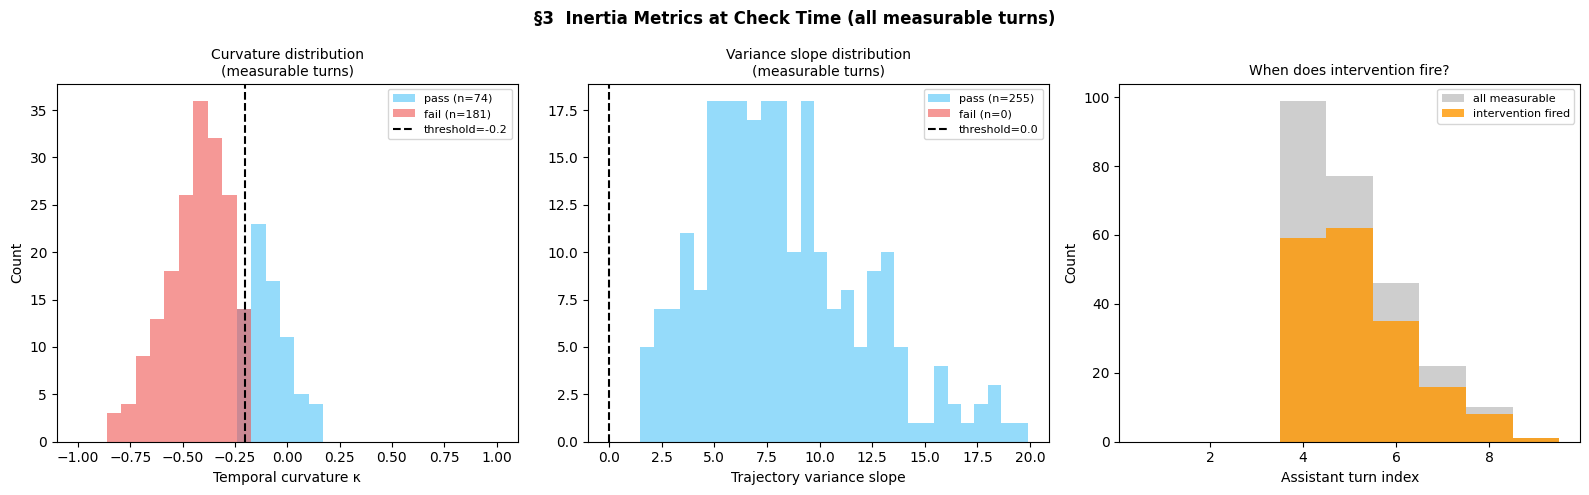

In [139]:
# ── 3.2 Metric distribution at intervention turns ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("§3  Inertia Metrics at Check Time (all measurable turns)",
             fontsize=12, fontweight="bold")

# --- Panel A: curvature histogram split by intervention ---
ax = axes[0]
curv_pass = [e["curvature"] for e in all_measurable
             if e["curvature"] is not None and not e["curvature_fail"]]
curv_fail = [e["curvature"] for e in all_measurable
             if e["curvature"] is not None and e["curvature_fail"]]
bins = np.linspace(-1.0, 1.0, 30)
ax.hist(curv_pass, bins=bins, alpha=0.6, color="#4fc3f7", label=f"pass (n={len(curv_pass)})")
ax.hist(curv_fail, bins=bins, alpha=0.6, color="#ef5350", label=f"fail (n={len(curv_fail)})")
ax.axvline(CURV_THRESHOLD, lw=1.5, ls="--", color="black", label=f"threshold={CURV_THRESHOLD}")
ax.set_xlabel("Temporal curvature κ", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Curvature distribution\n(measurable turns)", fontsize=10)
ax.legend(fontsize=8)

# --- Panel B: var_slope histogram ---
ax = axes[1]
var_pass = [e["var_slope"] for e in all_measurable
            if e["var_slope"] is not None and not e["var_slope_fail"]]
var_fail = [e["var_slope"] for e in all_measurable
            if e["var_slope"] is not None and e["var_slope_fail"]]
# clip for readability
clip = np.percentile([e["var_slope"] for e in all_measurable if e["var_slope"] is not None], [2, 98])
all_var = [e["var_slope"] for e in all_measurable if e["var_slope"] is not None]
bins_v = np.linspace(clip[0], clip[1], 30)
ax.hist(var_pass, bins=bins_v, alpha=0.6, color="#4fc3f7", label=f"pass (n={len(var_pass)})")
ax.hist(var_fail, bins=bins_v, alpha=0.6, color="#ef5350", label=f"fail (n={len(var_fail)})")
ax.axvline(VAR_THRESHOLD, lw=1.5, ls="--", color="black", label=f"threshold={VAR_THRESHOLD}")
ax.set_xlabel("Trajectory variance slope", fontsize=10)
ax.set_title("Variance slope distribution\n(measurable turns)", fontsize=10)
ax.legend(fontsize=8)

# --- Panel C: intervention turn distribution ---
ax = axes[2]
turns_all  = [e["assistant_turn"] for e in all_measurable]
turns_intv = [e["assistant_turn"] for e in all_interventions]
max_turn   = max(turns_all) if turns_all else 10
bins_t     = np.arange(1, max_turn + 2) - 0.5
ax.hist(turns_all,  bins=bins_t, alpha=0.5, color="#9e9e9e", label="all measurable")
ax.hist(turns_intv, bins=bins_t, alpha=0.8, color="#ff9800", label="intervention fired")
ax.set_xlabel("Assistant turn index", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("When does intervention fire?", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## §4  Accuracy: Baseline vs Intervention Run

**Note:** the inertia run currently has n=19; confidence intervals are wide.  
Treat this as a calibration check, not a statistically conclusive result.

In [140]:
# ── 4.1 Overall accuracy table with 95% CI ───────────────────────────────────

groups = {
    "Baseline (no inertia)"       : baseline_recs,
    "Inertia run (all)"           : inertia_recs,
    "Inertia — no intervention"   : [r for r in inertia_recs if r["n_interventions"] == 0],
    "Inertia — ≥1 intervention"  : [r for r in inertia_recs if r["n_interventions"] > 0],
    "Inertia — ≥2 interventions" : [r for r in inertia_recs if r["n_interventions"] >= 2],
}

print(f"{'Group':<35}  {'n':>5}  {'correct':>7}  {'accuracy':>9}  {'95% CI':>18}")
print("─" * 80)
for label, recs in groups.items():
    n  = len(recs)
    nc = sum(r["score"] for r in recs)
    if n == 0:
        print(f"{label:<35}  {'—':>5}  {'—':>7}  {'—':>9}  {'—':>18}")
        continue
    acc = nc / n
    lo, hi = ci95_proportion(nc, n)
    print(f"{label:<35}  {n:>5}  {nc:>7}  {acc:>9.3f}  [{lo:.3f}, {hi:.3f}]")

Group                                    n  correct   accuracy              95% CI
────────────────────────────────────────────────────────────────────────────────
Baseline (no inertia)                  241      128      0.531  [0.468, 0.593]
Inertia run (all)                      101       40      0.396  [0.306, 0.494]
Inertia — no intervention               19        9      0.474  [0.273, 0.683]
Inertia — ≥1 intervention               82       31      0.378  [0.281, 0.486]
Inertia — ≥2 interventions              57       23      0.404  [0.286, 0.533]


In [141]:
# ── 4.2 Fisher exact test: baseline vs inertia run ───────────────────────────
# Tests whether the accuracy difference could be due to chance.

n_b  = len(baseline_recs)
nc_b = sum(r["score"] for r in baseline_recs)
n_i  = len(inertia_recs)
nc_i = sum(r["score"] for r in inertia_recs)

table = [[nc_b, n_b - nc_b],
         [nc_i, n_i - nc_i]]
or_val, p_fisher = fisher_exact(table, alternative="two-sided")
print(f"Fisher exact test (baseline vs inertia run):")
print(f"  Baseline  : {nc_b}/{n_b} correct")
print(f"  Inertia   : {nc_i}/{n_i} correct")
print(f"  Odds ratio: {or_val:.3f}")
print(f"  p-value   : {p_fisher:.4g}")
if p_fisher < 0.05:
    print(f"  → Significant at α=0.05")
else:
    print(f"  → Not significant (n={n_i} inertia runs is likely too small)")

Fisher exact test (baseline vs inertia run):
  Baseline  : 128/241 correct
  Inertia   : 40/101 correct
  Odds ratio: 1.727
  p-value   : 0.02463
  → Significant at α=0.05


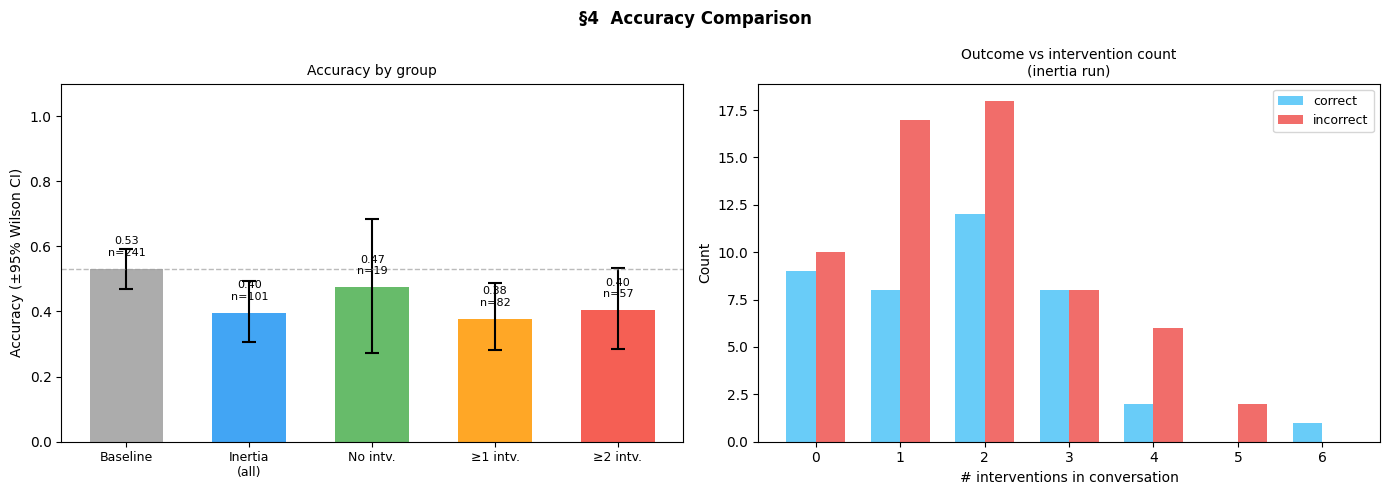

In [142]:
# ── 4.3 Visualise accuracy with error bars ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("§4  Accuracy Comparison", fontsize=12, fontweight="bold")

# --- Panel A: bar chart with CI ---
ax = axes[0]
labels_plot = ["Baseline", "Inertia\n(all)", "No intv.", "≥1 intv.", "≥2 intv."]
accs, lo_errs, hi_errs, ns = [], [], [], []
for label, recs in groups.items():
    n  = len(recs)
    nc = sum(r["score"] for r in recs)
    if n == 0:
        accs.append(0); lo_errs.append(0); hi_errs.append(0); ns.append(0)
        continue
    acc = nc / n
    lo, hi = ci95_proportion(nc, n)
    accs.append(acc)
    lo_errs.append(acc - lo)
    hi_errs.append(hi - acc)
    ns.append(n)

colors = ["#9e9e9e", "#2196F3", "#4CAF50", "#FF9800", "#F44336"]
x = np.arange(len(labels_plot))
bars = ax.bar(x, accs, 0.6, color=colors, alpha=0.85)
ax.errorbar(x, accs, yerr=[lo_errs, hi_errs], fmt="none",
            ecolor="black", elinewidth=1.5, capsize=5, capthick=1.5)
ax.axhline(accs[0], lw=1, ls="--", color="#9e9e9e", alpha=0.7, label="baseline")
for xi, (acc, n) in enumerate(zip(accs, ns)):
    ax.text(xi, acc + 0.04, f"{acc:.2f}\nn={n}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy (±95% Wilson CI)", fontsize=10)
ax.set_title("Accuracy by group", fontsize=10)

# --- Panel B: number of interventions per conv vs outcome ---
ax = axes[1]
n_intv_correct   = Counter(r["n_interventions"] for r in inertia_recs if r["score"] == 1)
n_intv_incorrect = Counter(r["n_interventions"] for r in inertia_recs if r["score"] == 0)
all_n_intv = sorted(set(n_intv_correct) | set(n_intv_incorrect))
width = 0.35
ax.bar([i - width/2 for i in range(len(all_n_intv))],
       [n_intv_correct.get(k, 0) for k in all_n_intv],
       width, label="correct", color="#4fc3f7", alpha=0.85)
ax.bar([i + width/2 for i in range(len(all_n_intv))],
       [n_intv_incorrect.get(k, 0) for k in all_n_intv],
       width, label="incorrect", color="#ef5350", alpha=0.85)
ax.set_xticks(range(len(all_n_intv)))
ax.set_xticklabels([str(k) for k in all_n_intv])
ax.set_xlabel("# interventions in conversation", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Outcome vs intervention count\n(inertia run)", fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## §5  Trajectory Recovery

After an intervention fires at turn *t*, does the hidden-state trajectory recover?  
We compare κ and variance slope **before** vs **after** the intervention turn.

In [143]:
# ── 5.1 Build per-conversation curvature sequence from .pt files ──────────────
# For each inertia conversation with ≥1 intervention, compute κ at every
# measurable turn and label each turn as pre/post first intervention.

def curvature_sequence(turn_states: list[np.ndarray]) -> list[float]:
    """Returns κ for indices 2..(T-1) in turn_states (i.e. turn ≥ 3)."""
    kappas = []
    for i in range(2, len(turn_states)):
        kappas.append(cosine(turn_states[i] - turn_states[i-1],
                             turn_states[i-1] - turn_states[i-2]))
    return kappas

def var_slope_at_t(turn_states: list[np.ndarray], t: int) -> float:
    """Variance slope using prefix up to index t (0-based into turn_states)."""
    if t < 2: return float("nan")
    hs = np.stack(turn_states[:t+1])
    T  = len(hs)
    trace_covs = [float(hs[:k].var(axis=0).sum()) for k in range(2, T+1)]
    if len(trace_covs) < 2: return float("nan")
    return (trace_covs[-1] - trace_covs[0]) / max(len(trace_covs) - 1, 1)

# Build recovery records
recovery_records = []

for rec in inertia_recs:
    cid   = rec["conv_id"]
    score = rec["score"]
    hs    = hs_inertia.get(cid)
    if hs is None: continue

    # turn states only (skip goal at index 0)
    turn_states = hs[1:]
    if len(turn_states) < 4: continue   # need at least 4 turns for pre/post

    kappas = curvature_sequence(turn_states)   # length = len(turn_states) - 2
    # kappas[i] = curvature at turn index i+2 (0-based into turn_states)

    # Find first intervention turn (assistant_turn is 1-indexed into generate calls)
    first_intv = next((e for e in rec["inertia_events"] if e["intervened"]), None)
    if first_intv is None: continue

    # Map assistant_turn → 0-based turn_states index
    # assistant_turn=1 → turn_states[0] (generated from that state)
    # intervention before assistant_turn=k → turn_states index = k-1
    intv_ts_idx = first_intv["assistant_turn"] - 1  # turn state that triggered the check

    # κ before intervention: the last curvature computed before intv_ts_idx
    # κ[i] is at turn_states[i+2], so κ before = kappas[intv_ts_idx - 2] if valid
    if intv_ts_idx < 2: continue
    kappa_at_intv = kappas[intv_ts_idx - 2] if (intv_ts_idx - 2) < len(kappas) else float("nan")
    kappa_after   = kappas[intv_ts_idx - 1] if (intv_ts_idx - 1) < len(kappas) else float("nan")

    vslope_before = var_slope_at_t(turn_states, intv_ts_idx)
    vslope_after  = var_slope_at_t(turn_states, min(intv_ts_idx + 2, len(turn_states) - 1))

    recovery_records.append({
        "conv_id"       : cid,
        "score"         : score,
        "intv_turn"     : first_intv["assistant_turn"],
        "kappa_at_intv" : kappa_at_intv,
        "kappa_after"   : kappa_after,
        "delta_kappa"   : kappa_after - kappa_at_intv if not (math.isnan(kappa_at_intv) or math.isnan(kappa_after)) else float("nan"),
        "vslope_before" : vslope_before,
        "vslope_after"  : vslope_after,
        "delta_vslope"  : vslope_after - vslope_before if not (math.isnan(vslope_before) or math.isnan(vslope_after)) else float("nan"),
    })

print(f"Recovery records: {len(recovery_records)}")
valid_dk = [r["delta_kappa"] for r in recovery_records if not math.isnan(r["delta_kappa"])]
valid_dv = [r["delta_vslope"] for r in recovery_records if not math.isnan(r["delta_vslope"])]
if valid_dk: print(f"Δκ after intervention: mean={np.mean(valid_dk):+.3f}  (positive = improved momentum)")
if valid_dv: print(f"Δvar_slope           : mean={np.mean(valid_dv):+.1f}  (positive = expanded exploration)")

Recovery records: 71
Δκ after intervention: mean=+0.044  (positive = improved momentum)
Δvar_slope           : mean=-1.0  (positive = expanded exploration)


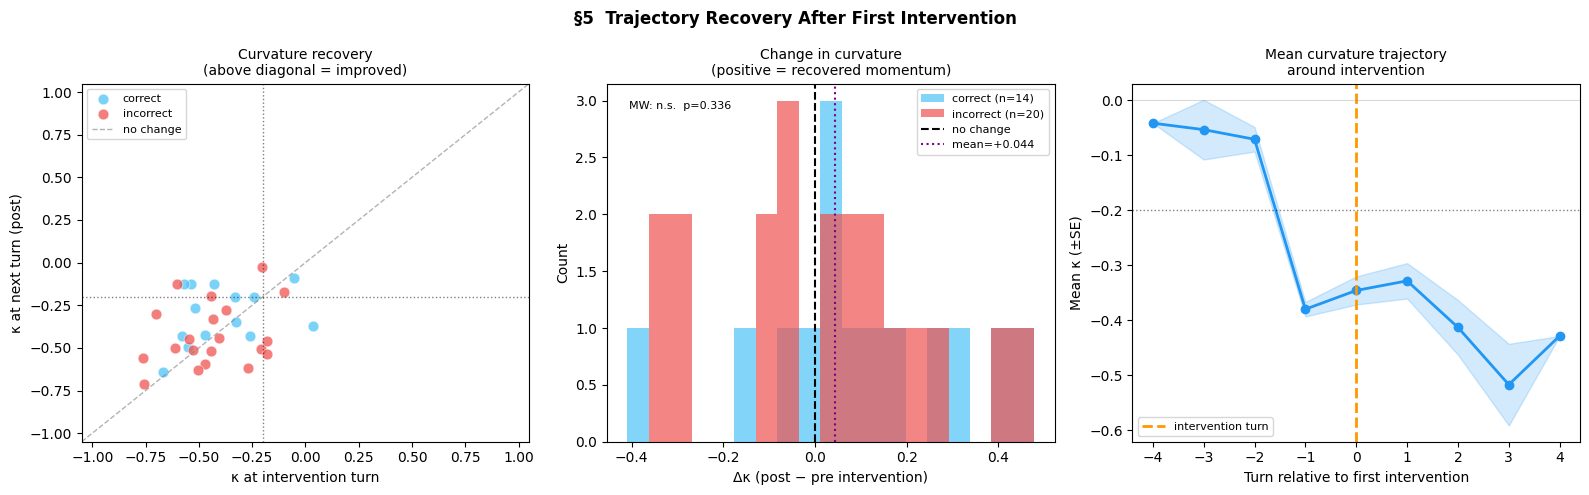

In [144]:
# ── 5.2 Visualise trajectory recovery ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("§5  Trajectory Recovery After First Intervention",
             fontsize=12, fontweight="bold")

# --- Panel A: κ before vs after intervention, by outcome ---
ax = axes[0]
for score, clr, lbl in [(1, "#4fc3f7", "correct"), (0, "#ef5350", "incorrect")]:
    pts = [(r["kappa_at_intv"], r["kappa_after"]) for r in recovery_records
           if r["score"] == score
           and not math.isnan(r["kappa_at_intv"])
           and not math.isnan(r["kappa_after"])]
    if pts:
        xs, ys = zip(*pts)
        ax.scatter(xs, ys, s=60, color=clr, alpha=0.75, label=lbl, edgecolors="white", linewidths=0.5)
lim = (-1.05, 1.05)
ax.plot(lim, lim, lw=1, ls="--", color="gray", alpha=0.6, label="no change")
ax.axvline(CURV_THRESHOLD, lw=1, ls=":", color="black", alpha=0.5)
ax.axhline(CURV_THRESHOLD, lw=1, ls=":", color="black", alpha=0.5)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel("κ at intervention turn", fontsize=10)
ax.set_ylabel("κ at next turn (post)", fontsize=10)
ax.set_title("Curvature recovery\n(above diagonal = improved)", fontsize=10)
ax.legend(fontsize=8)

# --- Panel B: Δκ distribution (post − pre) ---
ax = axes[1]
dk_c = [r["delta_kappa"] for r in recovery_records
        if r["score"]==1 and not math.isnan(r["delta_kappa"])]
dk_i = [r["delta_kappa"] for r in recovery_records
        if r["score"]==0 and not math.isnan(r["delta_kappa"])]
all_dk = dk_c + dk_i
if all_dk:
    bins = np.linspace(min(all_dk), max(all_dk), 20)
    ax.hist(dk_c, bins=bins, alpha=0.7, color="#4fc3f7", label=f"correct (n={len(dk_c)})")
    ax.hist(dk_i, bins=bins, alpha=0.7, color="#ef5350", label=f"incorrect (n={len(dk_i)})")
    ax.axvline(0, lw=1.5, ls="--", color="black", label="no change")
    if valid_dk:
        ax.axvline(np.mean(all_dk), lw=1.5, ls=":", color="purple",
                   label=f"mean={np.mean(all_dk):+.3f}")
ax.set_xlabel("Δκ (post − pre intervention)", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Change in curvature\n(positive = recovered momentum)", fontsize=10)
ax.legend(fontsize=8)

star_dk, p_dk = mw_test(dk_c, dk_i)
ax.text(0.05, 0.95, f"MW: {star_dk}  p={p_dk:.3g}", transform=ax.transAxes,
        fontsize=8, va="top")

# --- Panel C: mean curvature trajectory around intervention turn ---
ax = axes[2]
# Align to intervention turn (relative position)
rel_kappa: dict[int, list] = defaultdict(list)
for rec in inertia_recs:
    cid   = rec["conv_id"]
    hs    = hs_inertia.get(cid)
    if hs is None: continue
    turn_states = hs[1:]
    if len(turn_states) < 3: continue
    kappas = curvature_sequence(turn_states)
    # find first intervention index
    first_intv = next((e for e in rec["inertia_events"] if e["intervened"]), None)
    if first_intv is None:
        anchor = 0   # no intervention: align to turn 3
    else:
        anchor = first_intv["assistant_turn"] - 1 - 2  # kappas index of intervention
    for ki, kappa in enumerate(kappas):
        if not math.isnan(kappa):
            rel_pos = ki - anchor
            rel_kappa[rel_pos].append(kappa)

rel_positions = sorted(k for k in rel_kappa if -4 <= k <= 4)
means  = [np.mean(rel_kappa[p]) for p in rel_positions]
ses    = [np.std(rel_kappa[p]) / math.sqrt(len(rel_kappa[p])) for p in rel_positions]
ax.plot(rel_positions, means, "o-", color="#2196F3", lw=2)
ax.fill_between(rel_positions,
                [m - s for m, s in zip(means, ses)],
                [m + s for m, s in zip(means, ses)],
                alpha=0.2, color="#2196F3")
ax.axvline(0, lw=2, ls="--", color="#FF9800", label="intervention turn")
ax.axhline(CURV_THRESHOLD, lw=1, ls=":", color="black", alpha=0.5)
ax.axhline(0, lw=0.8, ls="-", color="gray", alpha=0.3)
ax.set_xlabel("Turn relative to first intervention", fontsize=10)
ax.set_ylabel("Mean κ (±SE)", fontsize=10)
ax.set_title("Mean curvature trajectory\naround intervention", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## §6  Threshold Calibration

Using the inertia run data, find where to set the two thresholds for best
precision/recall trade-off at predicting incorrect conversations.

In [145]:
# ── 6.1 Build per-check outcome labels from baseline .pt files ────────────────
# For calibration we use the larger baseline corpus (241 runs) where we have
# ground-truth scores.  We simulate what curvature and var_slope the checker
# WOULD have computed at each turn, then treat the conversation outcome as label.

calib_records = []

for cid, hs in hs_baseline.items():
    score = score_map_baseline.get(cid)
    if score is None: continue
    turn_states = hs[1:]  # skip goal
    if len(turn_states) < 3: continue

    # Mean curvature across all measurable turns in this conversation
    kappas = [k for k in curvature_sequence(turn_states) if not math.isnan(k)]
    mean_kappa = np.mean(kappas) if kappas else float("nan")

    # Variance slope over the whole conversation
    hs_stack = np.stack(turn_states)
    T = len(hs_stack)
    trace_covs = [float(hs_stack[:t].var(axis=0).sum()) for t in range(2, T+1)]
    if len(trace_covs) >= 2:
        vslope = (trace_covs[-1] - trace_covs[0]) / max(len(trace_covs) - 1, 1)
    else:
        vslope = float("nan")

    # Earliest curvature (turn 3 if available)
    early_kappa = kappas[0] if kappas else float("nan")

    calib_records.append({
        "conv_id"    : cid,
        "score"      : score,
        "mean_kappa" : mean_kappa,
        "early_kappa": early_kappa,
        "vslope"     : vslope,
        "n_turns"    : len(turn_states),
    })

print(f"Calibration records (baseline): {len(calib_records)}")
valid_mk = [r for r in calib_records if not math.isnan(r["mean_kappa"])]
valid_vs = [r for r in calib_records if not math.isnan(r["vslope"])]
print(f"  with valid mean_kappa : {len(valid_mk)}")
print(f"  with valid vslope     : {len(valid_vs)}")

# Quick AUROC check
if len(valid_mk) > 10:
    labs = [r["score"] for r in valid_mk]
    vals = [r["mean_kappa"] for r in valid_mk]
    auc_k = roc_auc_score(labs, vals)
    auc_k_neg = roc_auc_score(labs, [-v for v in vals])
    print(f"\nAUROC (mean_kappa → correct): {max(auc_k, auc_k_neg):.4f}")
if len(valid_vs) > 10:
    labs = [r["score"] for r in valid_vs]
    vals = [r["vslope"] for r in valid_vs]
    auc_v = roc_auc_score(labs, vals)
    auc_v_neg = roc_auc_score(labs, [-v for v in vals])
    print(f"AUROC (vslope       → correct): {max(auc_v, auc_v_neg):.4f}")

Calibration records (baseline): 219
  with valid mean_kappa : 219
  with valid vslope     : 219

AUROC (mean_kappa → correct): 0.6444
AUROC (vslope       → correct): 0.6137


mean_kappa: AUC=0.6444  Youden-J optimal threshold=-0.2394  (currently using -0.2)
var_slope: AUC=0.6137  Youden-J optimal threshold=7.2591  (currently using 0.0)


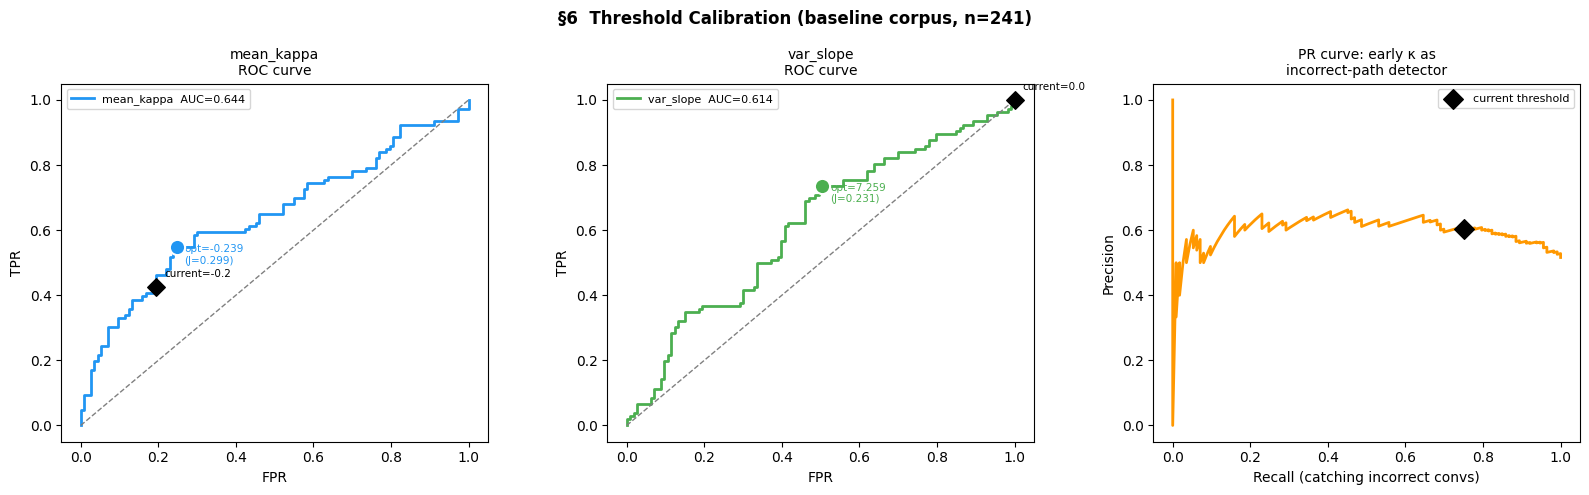

In [146]:
# ── 6.2 ROC curves + optimal thresholds ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("§6  Threshold Calibration (baseline corpus, n=241)",
             fontsize=12, fontweight="bold")

def plot_roc_with_threshold(ax, labs, raw_vals, label, color, current_threshold,
                             higher_is_correct=True):
    vals = raw_vals if higher_is_correct else [-v for v in raw_vals]
    if len(set(labs)) < 2:
        ax.text(0.5, 0.5, "only one class", ha="center", transform=ax.transAxes)
        return
    fpr, tpr, thresholds = roc_curve(labs, vals)
    auc = roc_auc_score(labs, vals)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{label}  AUC={auc:.3f}")
    ax.plot([0,1],[0,1], lw=1, ls="--", color="gray")

    # Mark Youden-J optimal threshold
    j = tpr - fpr
    best_idx = np.argmax(j)
    best_thr = thresholds[best_idx]
    if not higher_is_correct: best_thr = -best_thr
    ax.scatter(fpr[best_idx], tpr[best_idx], s=120, color=color, zorder=5,
               edgecolors="white", linewidths=1.5)
    ax.text(fpr[best_idx] + 0.02, tpr[best_idx] - 0.05,
            f"opt={best_thr:.3f}\n(J={j[best_idx]:.3f})",
            fontsize=7.5, color=color)

    # Mark current threshold
    thr_vals = thresholds if higher_is_correct else [-t for t in thresholds]
    diffs    = np.abs(thr_vals - current_threshold)
    cur_idx  = np.argmin(diffs)
    ax.scatter(fpr[cur_idx], tpr[cur_idx], s=80, marker="D", color="black", zorder=5)
    ax.text(fpr[cur_idx] + 0.02, tpr[cur_idx] + 0.03,
            f"current={current_threshold}", fontsize=7.5)

    ax.set_xlabel("FPR", fontsize=10); ax.set_ylabel("TPR", fontsize=10)
    ax.set_title(f"{label}\nROC curve", fontsize=10)
    ax.legend(fontsize=8)

    print(f"{label}: AUC={auc:.4f}  Youden-J optimal threshold={best_thr:.4f}  "
          f"(currently using {current_threshold})")

# Mean curvature
mk_labs = [r["score"] for r in valid_mk]
mk_vals = [r["mean_kappa"] for r in valid_mk]
plot_roc_with_threshold(axes[0], mk_labs, mk_vals,
                         "mean_kappa", "#2196F3", CURV_THRESHOLD, higher_is_correct=True)

# Variance slope
vs_labs = [r["score"] for r in valid_vs]
vs_vals = [r["vslope"] for r in valid_vs]
plot_roc_with_threshold(axes[1], vs_labs, vs_vals,
                         "var_slope", "#4CAF50", VAR_THRESHOLD, higher_is_correct=True)

# --- Panel C: Precision-Recall for early_kappa (intervention precision) ---
ax = axes[2]
ek_recs = [r for r in calib_records if not math.isnan(r["early_kappa"])]
ek_labs = [r["score"] for r in ek_recs]
ek_vals = [r["early_kappa"] for r in ek_recs]
# Intervention fires when kappa < threshold → we want to catch incorrect (label=0)
# Invert: "intervention on incorrect" = TP
if len(set(ek_labs)) > 1:
    neg_labs = [1 - l for l in ek_labs]  # 1=incorrect is the positive class for intervention
    prec, rec_vals, thr_pr = precision_recall_curve(neg_labs, [-v for v in ek_vals])
    ax.plot(rec_vals, prec, lw=2, color="#FF9800")
    # Mark current threshold
    cur_pr_idx = np.argmin(np.abs(thr_pr - (-CURV_THRESHOLD)))
    ax.scatter(rec_vals[cur_pr_idx], prec[cur_pr_idx], s=100, color="black",
               marker="D", zorder=5, label=f"current threshold")
    ax.set_xlabel("Recall (catching incorrect convs)", fontsize=10)
    ax.set_ylabel("Precision", fontsize=10)
    ax.set_title("PR curve: early κ as\nincorrect-path detector", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [147]:
# ── 6.3 Threshold sweep: intervention rate vs estimated accuracy gain ─────────
# Simulate: for each threshold, count what fraction of conversations would
# be intervened on, and what fraction of those were incorrect (precision).

print("Threshold sweep — temporal curvature (mean per conversation):")
print(f"{'threshold':>12}  {'intv_rate':>10}  {'precision':>10}  {'recall':>8}")
print("─" * 50)

thresholds_sweep = np.arange(-0.5, 0.1, 0.05)
for thr in thresholds_sweep:
    intervened = [r for r in valid_mk if r["mean_kappa"] < thr]
    n_intv = len(intervened)
    if n_intv == 0:
        print(f"{thr:>12.2f}  {0:>10.3f}  {'—':>10}  {'—':>8}")
        continue
    n_incorr_caught = sum(1 for r in intervened if r["score"] == 0)
    precision = n_incorr_caught / n_intv
    n_total_incorr = sum(1 for r in valid_mk if r["score"] == 0)
    recall = n_incorr_caught / n_total_incorr if n_total_incorr > 0 else 0
    intv_rate = n_intv / len(valid_mk)
    marker = " ◀" if abs(thr - CURV_THRESHOLD) < 0.01 else ""
    print(f"{thr:>12.2f}  {intv_rate:>10.3f}  {precision:>10.3f}  {recall:>8.3f}{marker}")

Threshold sweep — temporal curvature (mean per conversation):
   threshold   intv_rate   precision    recall
──────────────────────────────────────────────────
       -0.50       0.078       0.588     0.088
       -0.45       0.123       0.704     0.168
       -0.40       0.187       0.585     0.212
       -0.35       0.283       0.597     0.327
       -0.30       0.402       0.614     0.478
       -0.25       0.584       0.625     0.708
       -0.20       0.689       0.603     0.805 ◀
       -0.15       0.776       0.588     0.885
       -0.10       0.854       0.572     0.947
       -0.05       0.904       0.556     0.973
       -0.00       0.968       0.528     0.991
        0.05       0.991       0.521     1.000


## §7  Summary & Recommendations

/tmp/ipykernel_545209/2288901.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


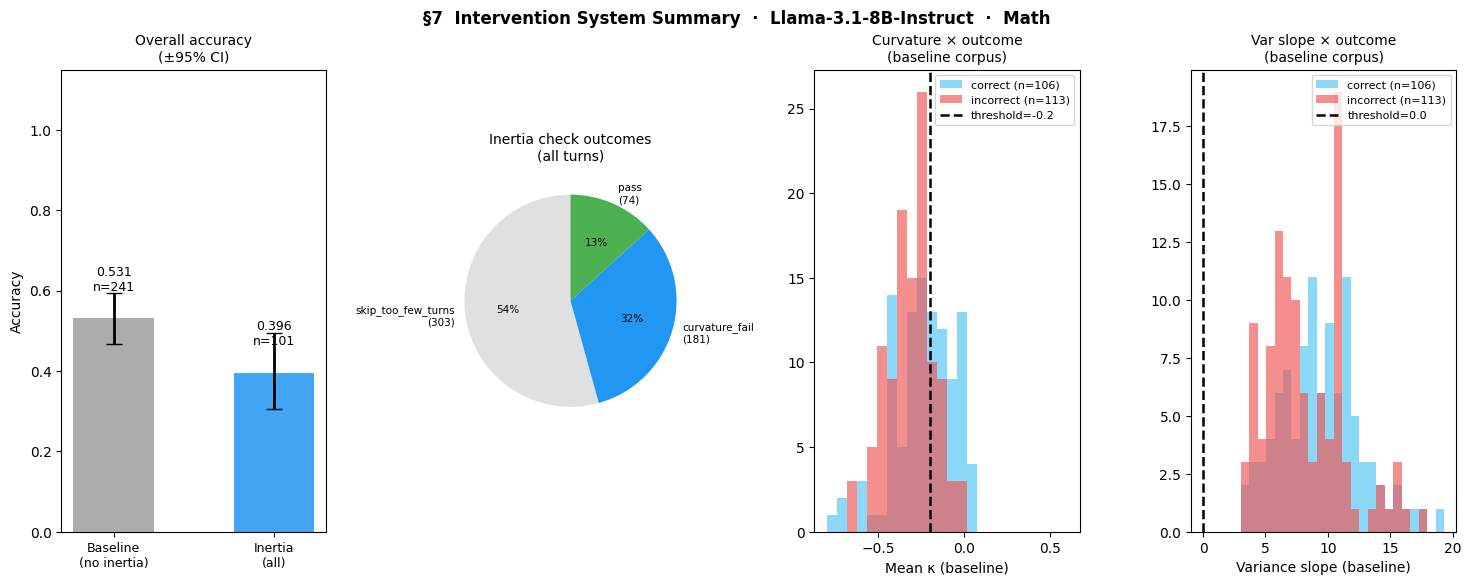


════════════════════════════════════════════════════════════
FINDINGS & RECOMMENDATIONS
════════════════════════════════════════════════════════════

1. Accuracy  : baseline=0.531  inertia=0.396
   Fisher p  : 0.02463  (significant)

2. Dominant failure mode : [('skip_too_few_turns', 303), ('curvature_fail', 181)]
   → curvature_fail fires most; var_slope_fail rare (var_slope ≈ always positive)
   → Consider RAISING var_slope_threshold to make it fire more

3. Mean κ   : correct=-0.237  incorrect=-0.308
   Current threshold: -0.2
   Midpoint of means: -0.272  (rough optimal threshold estimate)

4. To collect more data: run with --inertia_check and increase N_sharded_runs
   Minimum for meaningful comparison: ~100 inertia runs
════════════════════════════════════════════════════════════


In [148]:
# ── §7 Summary dashboard ──────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.42)
fig.suptitle("§7  Intervention System Summary  ·  Llama-3.1-8B-Instruct  ·  Math",
             fontsize=12, fontweight="bold")

# Panel A — accuracy comparison (baseline vs inertia)
ax = fig.add_subplot(gs[0])
group_labels = ["Baseline\n(no inertia)", "Inertia\n(all)"]
group_accs   = [n_bc/len(baseline_recs), n_ic/len(inertia_recs)]
group_cis    = [ci95_proportion(n_bc, len(baseline_recs)),
                ci95_proportion(n_ic, len(inertia_recs))]
group_ns     = [len(baseline_recs), len(inertia_recs)]
group_colors = ["#9e9e9e", "#2196F3"]
for xi, (lbl, acc, ci, n, clr) in enumerate(zip(group_labels, group_accs, group_cis, group_ns, group_colors)):
    ax.bar(xi, acc, 0.5, color=clr, alpha=0.85)
    ax.errorbar(xi, acc, yerr=[[acc - ci[0]], [ci[1] - acc]],
                fmt="none", ecolor="black", elinewidth=2, capsize=6)
    ax.text(xi, acc + 0.07, f"{acc:.3f}\nn={n}", ha="center", fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(group_labels, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Accuracy", fontsize=10)
ax.set_title("Overall accuracy\n(±95% CI)", fontsize=10)

# Panel B — intervention rate breakdown (reasons pie)
ax = fig.add_subplot(gs[1])
pie_labels = [k for k in reason_counts]
pie_sizes  = [reason_counts[k] for k in pie_labels]
pie_colors = {
    "skip_too_few_turns": "#e0e0e0",
    "pass"              : "#4CAF50",
    "curvature_fail"    : "#2196F3",
    "var_slope_fail"    : "#FF9800",
    "both_fail"         : "#F44336",
}
ax.pie(pie_sizes,
       labels=[f"{l}\n({v})" for l, v in zip(pie_labels, pie_sizes)],
       colors=[pie_colors.get(l, "#9e9e9e") for l in pie_labels],
       autopct="%1.0f%%", startangle=90, textprops={"fontsize": 7.5})
ax.set_title("Inertia check outcomes\n(all turns)", fontsize=10)

# Panel C — κ distribution (baseline corpus, correct vs incorrect)
ax = fig.add_subplot(gs[2])
kc = [r["mean_kappa"] for r in calib_records if not math.isnan(r["mean_kappa"]) and r["score"]==1]
ki = [r["mean_kappa"] for r in calib_records if not math.isnan(r["mean_kappa"]) and r["score"]==0]
bins_k = np.linspace(-0.8, 0.6, 25)
ax.hist(kc, bins=bins_k, alpha=0.65, color="#4fc3f7", label=f"correct (n={len(kc)})")
ax.hist(ki, bins=bins_k, alpha=0.65, color="#ef5350", label=f"incorrect (n={len(ki)})")
ax.axvline(CURV_THRESHOLD, lw=1.8, ls="--", color="black", label=f"threshold={CURV_THRESHOLD}")
ax.set_xlabel("Mean κ (baseline)", fontsize=10)
ax.set_title("Curvature × outcome\n(baseline corpus)", fontsize=10)
ax.legend(fontsize=8)

# Panel D — var_slope distribution
ax = fig.add_subplot(gs[3])
vc_v = [r["vslope"] for r in calib_records if not math.isnan(r["vslope"]) and r["score"]==1]
vi_v = [r["vslope"] for r in calib_records if not math.isnan(r["vslope"]) and r["score"]==0]
clip_v = np.percentile(vc_v + vi_v, [2, 98]) if (vc_v + vi_v) else (-100, 100)
bins_v = np.linspace(clip_v[0], clip_v[1], 25)
ax.hist(vc_v, bins=bins_v, alpha=0.65, color="#4fc3f7", label=f"correct (n={len(vc_v)})")
ax.hist(vi_v, bins=bins_v, alpha=0.65, color="#ef5350", label=f"incorrect (n={len(vi_v)})")
ax.axvline(VAR_THRESHOLD, lw=1.8, ls="--", color="black", label=f"threshold={VAR_THRESHOLD}")
ax.set_xlabel("Variance slope (baseline)", fontsize=10)
ax.set_title("Var slope × outcome\n(baseline corpus)", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Recommendations ────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("FINDINGS & RECOMMENDATIONS")
print("═"*60)
print(f"\n1. Accuracy  : baseline={n_bc/len(baseline_recs):.3f}  inertia={n_ic/len(inertia_recs):.3f}")
print(f"   Fisher p  : {p_fisher:.4g}  "
      f"({'significant' if p_fisher < 0.05 else 'not yet significant — need more inertia runs'})")
print(f"\n2. Dominant failure mode : {reason_counts.most_common(2)}")
print(f"   → curvature_fail fires most; var_slope_fail rare (var_slope ≈ always positive)")
print(f"   → Consider RAISING var_slope_threshold to make it fire more")

if valid_mk:
    mk_correct = np.mean([r["mean_kappa"] for r in valid_mk if r["score"]==1])
    mk_incorr  = np.mean([r["mean_kappa"] for r in valid_mk if r["score"]==0])
    print(f"\n3. Mean κ   : correct={mk_correct:+.3f}  incorrect={mk_incorr:+.3f}")
    print(f"   Current threshold: {CURV_THRESHOLD}")
    optimal_approx = (mk_correct + mk_incorr) / 2
    print(f"   Midpoint of means: {optimal_approx:+.3f}  (rough optimal threshold estimate)")

print(f"\n4. To collect more data: run with --inertia_check and increase N_sharded_runs")
print(f"   Minimum for meaningful comparison: ~100 inertia runs")
print("═"*60)